d:\Agentic AI Projects\Law Chatbot\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Dell\AppData\Local\Temp\ipykernel_173764\2999407359.py:14: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


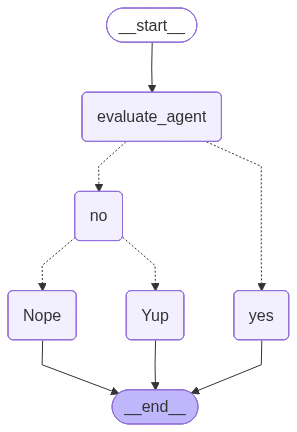

In [1]:
from typing import TypedDict , Literal , List
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from pydantic import BaseModel
from langgraph.graph import START , END , StateGraph
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

tavily = TavilySearchResults(max_results=5)
# emb = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
llm = ChatGroq(model = "llama-3.3-70b-versatile")

# db = FAISS.load_local("faiss_index_database", emb, allow_dangerous_deserialization=True)

# retriever = db.as_retriever(
#     search_type="mmr",   
#     search_kwargs={
#         "k": 5,         
#         "fetch_k": 20   
#     }
# )

class State(TypedDict):
    question : str
    evaluate_dec : Literal["yes" , "no"]
    answer : str
    general_gk : Literal["Yup" , "Nope"]

# Neurology , Gastroenterology , Nephrology , Hematology , Cardiology , General Medicine

def evaluate_agent(state: State)-> State:
    class pydant(BaseModel):
        decision : Literal["yes" , "no"]
    prompt = ChatPromptTemplate([("system",
                                  "You are a strict evaluator."
                                  "You will receive one question."
                                  "If that question is from following topics:"
                                  "Neurology , Gastroenterology , Nephrology , Hematology , Cardiology , General Medicine"
                                  "Then you have to return 'yes'"
                                  "Otherwise you have to return 'no'"
                                  "Give answer in given format only.") , 
                                  ("human",
                                   "Your question is : {question}")])
    chain = prompt | llm.with_structured_output(pydant)
    result = chain.invoke({"question" : state["question"]})
    return {"evaluate_dec" : result.decision}

def route1(state: State):
    if state["evaluate_dec"] == "yes":
        return "yes"
    else:
        return "no"
    
def yes(state: State)-> State:
    docs = retriever.get_relevant_documents(state["question"])
    context = "\n\n".join([doc.page_content for doc in docs])
    prompt = ChatPromptTemplate([("system",
                                   "You will recieve one question and the context."
                                   "You have to generate an answer from the given context only"
                                   "Don't include your own knowledge, just use the context"),
                                   ("human",
                                    "Your question : {question} and the context is : {context}")])
    
    chain = prompt | llm
    result = chain.invoke({"question" : state["question"],
                           "context" : context})
    return {"answer" : result.content}


def no(state: State)-> State:
    class pydant(BaseModel):
        decision : Literal["Yup" , "Nope"]
    prompt = ChatPromptTemplate([("system",
                                  "You are a strict evaluator"
                                  "You will recieve one question"
                                  "If you can answer that question from your knowledge return 'Yup'"
                                  "Other wise return 'Nope'"
                                  "Give answer in given format only") , 
                                  ("human",
                                   "Your question is : {question}")])
    chain = prompt | llm.with_structured_output(pydant)
    result = chain.invoke({"question" : state["question"]})
    return {"general_gk" : result.decision}

def route2(state: State):
    if state["general_gk"] == "Yup":
        return "Yup"
    else:
        return "Nope"

def Yup(state: State)-> State:
    prompt = ChatPromptTemplate([("system",
                                  "You will recieve one question"
                                  "You need to answer it from your general knowledge"),
                                  ("human",
                                   "Question : {question}")])
    
    chain = prompt | llm
    result = chain.invoke({"question" : state["question"]})

    return {"answer" : result.content}

def Nope(state: State)-> State:
    results = tavily.invoke({"query": state["question"]})
    web_docs: List[Document] = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    context = "\n\n".join([doc.page_content for doc in web_docs])
    prompt = ChatPromptTemplate([("system",
                                   "You will recieve one question and the context."
                                   "You have to generate an answer from the given context only"
                                   "Don't include your own knowledge, just use the context"),
                                   ("human",
                                    "Your question : {question} and the context is : {context}")])
    
    chain = prompt | llm
    result = chain.invoke({"question" : state["question"],
                           "context" : context})
    return {"answer" : result.content}
    

graph = StateGraph(State)

graph.add_node("evaluate_agent" , evaluate_agent)
graph.add_node("yes" , yes)
graph.add_node("no" , no)
graph.add_node("Yup" , Yup)
graph.add_node("Nope" , Nope)

graph.add_edge(START , "evaluate_agent")
graph.add_conditional_edges("evaluate_agent" , route1,
                            {"yes" : "yes",
                             "no" : "no"})
graph.add_edge("yes" , END)
graph.add_conditional_edges("no" , route2,
                            {"Yup" : "Yup",
                             "Nope" : "Nope"})
graph.add_edge("Yup" , END)
graph.add_edge("Nope" , END)

workflow = graph.compile()

workflow